In [1]:
# Importa libs necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carrega o dataset
df = pd.read_csv("../data/customer_churn_with_months.csv")

# Exibe as primeiras linhas do dataset
df.head()

,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
0,1,Micro empresa,2016,Sim,até 5 funcionários,1,Não,NaN,automática,Pouco uso,...,Pouco uso,Pouco uso,Mês-a-mês,1,Yes,Boleto - pagamento único,29.85,29.85,Não,NaN
1,2,Pequena empresa,2018,Não,até 5 funcionários,34,Sim,Não,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Boleto - mês a mês,56.95,1889.50,Não,NaN
2,4,Pequena empresa,2016,Não,até 5 funcionários,45,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Cartão de crédito - pagamento único,42.30,1840.75,Não,NaN
3,7,Pequena empresa,2019,Não,6 ou mais funcionários,22,Sim,Sim,manual,Pouco uso,...,Uso frequente,Pouco uso,Mês-a-mês,1,Yes,Cartão de crédito - mês a mês,89.10,1949.40,Não,NaN
4,8,Micro empresa,2019,Não,até 5 funcionários,10,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Mês-a-mês,0,No,Boleto - mês a mês,29.75,301.90,Não,NaN


In [3]:
# Exibe as colunas
df.columns

Index(['ID', 'Tipo de empresa', 'Fundação da empresa',
       'Possui mais de um sócio', 'Funcionários', 'Meses de permanência ',
       'Utiliza serviços financeiros', 'PossuiContador',
       'Faz conciliação bancária',
       'Frequência de utilização de feature do sistema: Módulo financeiro',
       'Frequência de utilização de feature do sistema: Emissão de nota fiscal',
       'Frequência de utilização de feature do sistema: Integração bancária',
       'Frequência de utilização de feature do sistema: Módulo de vendas',
       'Frequência de utilização de feature do sistema: Relatórios',
       'Frequência de utilização de feature do sistema: Utilização de APIs de integração',
       'Contrato', 'Emite boletos', 'Emite boletos.1', 'Tipo de pagamento',
       'Receita mensal', 'Receita total', 'Churn', 'mes_churn'],
      dtype='str')

In [4]:
# Retirando espaços no ínicio e fim das colunas
df.columns = df.columns.str.strip()

In [5]:
df.columns

Index(['ID', 'Tipo de empresa', 'Fundação da empresa',
       'Possui mais de um sócio', 'Funcionários', 'Meses de permanência',
       'Utiliza serviços financeiros', 'PossuiContador',
       'Faz conciliação bancária',
       'Frequência de utilização de feature do sistema: Módulo financeiro',
       'Frequência de utilização de feature do sistema: Emissão de nota fiscal',
       'Frequência de utilização de feature do sistema: Integração bancária',
       'Frequência de utilização de feature do sistema: Módulo de vendas',
       'Frequência de utilização de feature do sistema: Relatórios',
       'Frequência de utilização de feature do sistema: Utilização de APIs de integração',
       'Contrato', 'Emite boletos', 'Emite boletos.1', 'Tipo de pagamento',
       'Receita mensal', 'Receita total', 'Churn', 'mes_churn'],
      dtype='str')

1. Verificar nulos nas colunas principais
2. Verificar duplicados
3. Calcular tempo médio de permanencia dos clientes que fizeram churn'

In [6]:
# Verificar nulos nas colunas principais
df.isnull().sum()

ID                                                                                     0
Tipo de empresa                                                                        0
Fundação da empresa                                                                    0
Possui mais de um sócio                                                                0
Funcionários                                                                           0
Meses de permanência                                                                   0
Utiliza serviços financeiros                                                           0
PossuiContador                                                                       682
Faz conciliação bancária                                                               0
Frequência de utilização de feature do sistema: Módulo financeiro                      0
Frequência de utilização de feature do sistema: Emissão de nota fiscal                 0
Frequência de utiliza

In [7]:
# Verificar duplicados
df.duplicated().sum()

np.int64(0)

In [8]:
# Tempo médio de permanência dos clientes que fizeram churn
tempo_medio_permanencia_churn = df[df["Churn"] == 'Sim']["Meses de permanência"].mean()
print(f'Tempo médio de permanência de clientes que fizeram churn: {tempo_medio_permanencia_churn:.2f} meses')

# Mediana de permanência dos clientes que fizeram churn
tempo_mediana_permanencia_churn = df[df["Churn"] == 'Sim']["Meses de permanência"].median()
print(f'Mediana de permanência de clientes que fizeram churn: {tempo_mediana_permanencia_churn:.2f} meses')

Tempo médio de permanência de clientes que fizeram churn: 17.98 meses
Mediana de permanência de clientes que fizeram churn: 10.00 meses


In [9]:
# Tempo médio de permanência dos clientes que não fizeram churn
tempo_medio_permanencia_sem_churn = df[df["Churn"] == "Não"]["Meses de permanência"].mean()
print(f"Tempo médio de permanência de clientes que não fizeram churn: {tempo_medio_permanencia_sem_churn:.2f} meses")

# Mediana de permanência dos clientes que não fizeram churn
tempo_mediana_permanencia_sem_churn = df[df["Churn"] == "Não"]["Meses de permanência"].median()
print(f"Mediana de permanência de clientes que não fizeram churn: {tempo_mediana_permanencia_sem_churn:.2f} meses")

Tempo médio de permanência de clientes que não fizeram churn: 37.57 meses
Mediana de permanência de clientes que não fizeram churn: 38.00 meses


### Contar quantos clientes fizeram churn por mês

In [10]:
churn_por_mes = df.loc[df["Churn"] == "Sim", "mes_churn"].value_counts().sort_index()
print(f'Quantidade de clientes que fizeram churn por mês:\n {churn_por_mes}')

Quantidade de clientes que fizeram churn por mês:
 mes_churn
04/2025    911
05/2025    958
Name: count, dtype: int64


### Total de clientes na nossa base

In [11]:
# Linhas = Clientes
len(df)

7043

### Percentual que cancelou em cada mês

In [12]:
percent_churn_por_mes = (churn_por_mes / len(df)) * 100

print(f'Percentual de clientes que fizeram churn por mês:\n{percent_churn_por_mes}')

Percentual de clientes que fizeram churn por mês:
mes_churn
04/2025    12.934829
05/2025    13.602158
Name: count, dtype: float64


### Tendência de Churn Mês a Mês

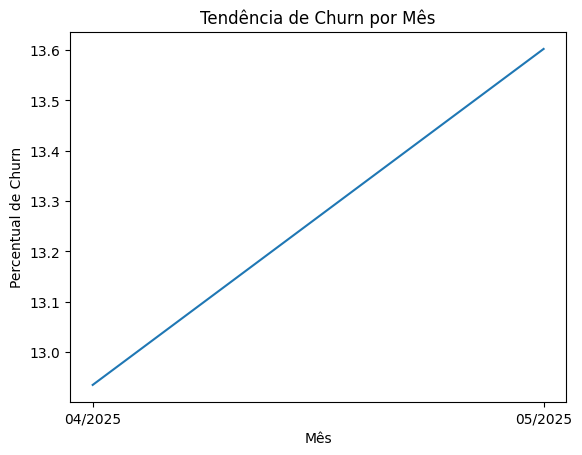

In [19]:
plt.title("Tendência de Churn por Mês")
plt.ylabel("Percentual de Churn")
plt.xlabel("Mês")
sns.lineplot(data=percent_churn_por_mes)
plt.show()

### Receita Total dos Clientes que fizeram Churn

In [22]:
receita_total_clientes_churn = df.loc[df["Churn"] == "Sim", "Receita mensal"].sum()
print(f"Receita total dos clientes que fizeram churn: R$ {receita_total_clientes_churn:.2f}")

Receita total dos clientes que fizeram churn: R$ 139130.85


In [23]:
receita_total_clientes_churn_porcentagem = (receita_total_clientes_churn / df["Receita mensal"].sum()) * 100
print(f"Receita total dos clientes que fizeram churn em relação à receita total: {receita_total_clientes_churn_porcentagem:.2f}%")

Receita total dos clientes que fizeram churn em relação à receita total: 30.50%


### Clientes que fizeram Churn possui Contador?

In [24]:
df.head()

,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
0,1,Micro empresa,2016,Sim,até 5 funcionários,1,Não,NaN,automática,Pouco uso,...,Pouco uso,Pouco uso,Mês-a-mês,1,Yes,Boleto - pagamento único,29.85,29.85,Não,NaN
1,2,Pequena empresa,2018,Não,até 5 funcionários,34,Sim,Não,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Boleto - mês a mês,56.95,1889.50,Não,NaN
2,4,Pequena empresa,2016,Não,até 5 funcionários,45,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Cartão de crédito - pagamento único,42.30,1840.75,Não,NaN
3,7,Pequena empresa,2019,Não,6 ou mais funcionários,22,Sim,Sim,manual,Pouco uso,...,Uso frequente,Pouco uso,Mês-a-mês,1,Yes,Cartão de crédito - mês a mês,89.10,1949.40,Não,NaN
4,8,Micro empresa,2019,Não,até 5 funcionários,10,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Mês-a-mês,0,No,Boleto - mês a mês,29.75,301.90,Não,NaN


### Verificar Clientes que fizeram Churn e Utilizam Serviços Financeiros

In [ ]:
# Cria DF com clientes que fizeram churn e utilizam serviços financeiros
clientes_churn_utiliza_servico_financeiro = df[(df["Churn"] == "Sim") & (df["Utiliza serviços financeiros"] == "Sim")]
clientes_churn_utiliza_servico_financeiro.head()

,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
5174,6445,Pequena empresa,2020,Não,6 ou mais funcionários,31,Sim,Sim,automática,Pouco uso,...,Uso frequente,Uso frequente,Trimestral,1,Yes,Boleto - mês a mês,79.45,2587.70,Sim,04/2025
5175,5635,Micro empresa,2017,Sim,6 ou mais funcionários,1,Sim,Não,não faz,Nunca utilizou,...,Nunca utilizou,Nunca utilizou,Mês-a-mês,1,Yes,Boleto - pagamento único,19.90,19.90,Sim,04/2025
5176,3529,Pequena empresa,2018,Não,até 5 funcionários,16,Sim,Não,não faz,Nunca utilizou,...,Nunca utilizou,Nunca utilizou,Mês-a-mês,1,Yes,Boleto - mês a mês,19.70,342.40,Sim,04/2025
5177,1058,Micro empresa,2018,Não,até 5 funcionários,10,Sim,Não,manual,Uso frequente,...,Uso frequente,Pouco uso,Mês-a-mês,1,Yes,Boleto - mês a mês,84.70,832.05,Sim,04/2025
5178,1580,Pequena empresa,2014,Sim,até 5 funcionários,12,Sim,Não,manual,Pouco uso,...,Pouco uso,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,80.45,950.20,Sim,04/2025


In [37]:
# Verifica a quantidade de clientes que fizeram churn e utilizam serviços financeiros
len(clientes_churn_utiliza_servico_financeiro)

1699

In [40]:
# Percentual dos clientes que fizeram churn e utilizam serviços financeiros
percentual_clientes_churn_utiliza_servico_financeiro = len(clientes_churn_utiliza_servico_financeiro) / len(df[df["Churn"] == "Sim"]) * 100
print(f"Percentual de clientes que fizeram churn e utilizam serviços financeiros: {percentual_clientes_churn_utiliza_servico_financeiro:.2f}%")


Percentual de clientes que fizeram churn e utilizam serviços financeiros: 90.90%


### Verifica Clientes que não fizeram Churn e Utilizam Serviços Financeiros

In [ ]:
# Cria DF com clientes que não fizeram churn e utilizam serviços financeiros

clientes_sem_churn_utiliza_servico_financeiro = df[(df["Churn"] == "Não") & (df["Utiliza serviços financeiros"] == "Sim")]

In [44]:
# Verifica a quantidade de clientes que não fizeram churn e utilizam serviços financeiros
len(clientes_sem_churn_utiliza_servico_financeiro)

4662

In [45]:
# Percentual dos clientes que não fizeram churn e utilizam serviços financeiros
percentual_clientes_sem_churn_utiliza_servico_financeiro = len(clientes_sem_churn_utiliza_servico_financeiro) / len(df[df["Churn"] == "Não"]) * 100
print(f"Percentual de clientes que não fizeram churn e utilizam serviços financeiros: {percentual_clientes_sem_churn_utiliza_servico_financeiro:.2f}%")

Percentual de clientes que não fizeram churn e utilizam serviços financeiros: 90.10%
